In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Preprocess and data augmentation 
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

#Prepare data for training
train_data = datagen.flow_from_directory(
    "/Users/mac/Desktop/VisualStd/CNN/data/data_set",
    target_size=(150,150),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    color_mode="rgb"   
)

#Prepare data for testing
val_data = datagen.flow_from_directory(
    "/Users/mac/Desktop/VisualStd/CNN/data/data_set",
    target_size=(150,150),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    color_mode="rgb"  
)

print("Classes:", train_data.class_indices)

Found 1624 images belonging to 7 classes.
Found 179 images belonging to 7 classes.
Classes: {'bike': 0, 'cars': 1, 'cats': 2, 'dogs': 3, 'flowers': 4, 'horses': 5, 'human': 6}


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define CNN model
model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(pool_size=(2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Dropout(0.5),

    # Fully connected layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),

    # Output layer
    Dense(7, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks to improve training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001
)

# Train model
history = model.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr]
)

# Evaluate model
test_loss, test_acc = model.evaluate(val_data)

# Display results
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Epoch 1/30
51/51 [==============================] - 25s 460ms/step - loss: 1.7781 - accuracy: 0.3196 - val_loss: 1.5331 - val_accuracy: 0.4302 - lr: 0.0010
Epoch 2/30
51/51 [==============================] - 25s 476ms/step - loss: 1.3751 - accuracy: 0.5092 - val_loss: 1.3457 - val_accuracy: 0.5419 - lr: 0.0010
Epoch 3/30
51/51 [==============================] - 25s 485ms/step - loss: 1.1263 - accuracy: 0.6176 - val_loss: 1.2327 - val_accuracy: 0.5642 - lr: 0.0010
Epoch 4/30
51/51 [==============================] - 25s 478ms/step - loss: 0.9381 - accuracy: 0.6638 - val_loss: 1.2900 - val_accuracy: 0.5754 - lr: 0.0010
Epoch 5/30
51/51 [==============================] - 25s 482ms/step - loss: 0.8764 - accuracy: 0.7007 - val_loss: 1.1341 - val_accuracy: 0.5922 - lr: 0.0010
Epoch 6/30
51/51 [==============================] - 24s 469ms/step - loss: 0.8393 - accuracy: 0.7063 - val_loss: 1.0949 - val_accuracy: 0.6369 - lr: 0.0010
Epoch 7/30
51/51 [==============================] - 25s 483ms/st

6/6 [==============================] - 2s 330ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.44      0.54        36
           1       0.70      0.83      0.76        42
           2       0.35      0.55      0.43        20
           3       0.58      0.35      0.44        20
           4       0.95      1.00      0.98        21
           5       0.85      0.85      0.85        20
           6       0.81      0.85      0.83        20

    accuracy                           0.69       179
   macro avg       0.71      0.70      0.69       179
weighted avg       0.71      0.69      0.69       179



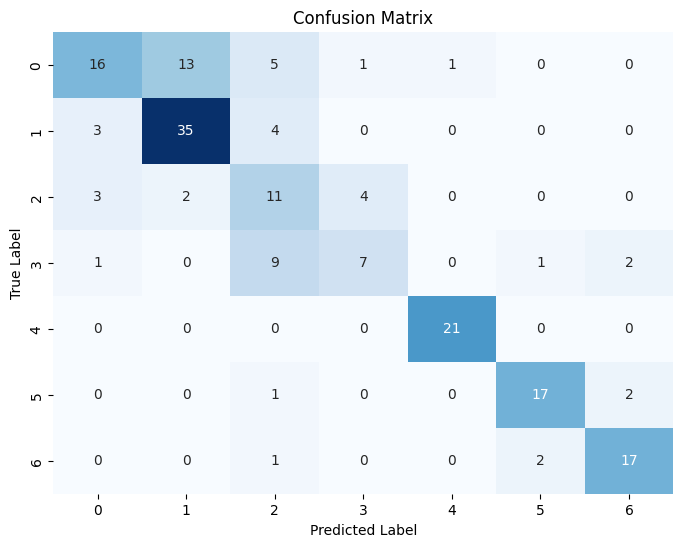

In [20]:
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


val_data.reset()

y_pred=model.predict(val_data)
y_pred_classes=np.argmax(y_pred,axis=1)
y_true=val_data.classes

print("Classification Report:\n")
print(classification_report(y_true,y_pred_classes))

conf_matrix=confusion_matrix(y_true,y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



In [11]:
model.save("image_classifier.h5")

/Users/mac/Desktop/VisualStd/CNN/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [21]:
import joblib
joblib.dump(history, 'svm_model.pkl')


['svm_model.pkl']